<a href="https://colab.research.google.com/github/danielulhoa-wq/MVP---Machine-Learning-Analytics/blob/main/MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Daniel Ulhoa Oliveira Miranda de Siqueira  
**Matrícula:** 4052026000363

**Data:** 01/06/2026  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Tipo de problema:** Clusterização



# 1. Definição do problema

## 1.1 Descrição do problema

* Análise de composição de pedidos de compra de e-commerces e identificação de grupos de produtos frequentemente consumidos em conjunto por diferentes clientes.

* Considerando o crescimento abrupto do e-commerce em 2020 alinhado à competitividade agressiva e contínua do meio online, o projeto beneficiará negócios do varejo físico e digital através da geração de insights (identificação de agrupamentos de itens chave) para expansão de sortimento, e criação de estratégias comerciais voltadas para o aumento da taxa de conversão e ticket médio dos pedidos.

## 1.2 Objetivo do MVP

Desenvolver e avaliar modelos de Machine Learning que realizem o clustering de produtos com padrões de ocorrências semelhantes dentro de pedidos de compra de um e-commerce estabelecendo uma abordagem baseline e um comparativo com modelos candidatos, visando possíveis melhorias.



## 1.3 Tipo de problema

**Tipo escolhido:** Clusterização

**Justificativa:** Deseja-se definir grupos de objetos (produtos) que possuam similaridades uns com os outros.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

1. A ocorrência conjunta será maior em itens de mesma categoria.

2. Um pequeno grupo de produtos representa a maior parte das relações de pedidos de compra em conjunto.

3. Existem relações relevantes de coocorências entre categorias distintas.

**Critérios de sucesso:**
- Métrica principal: Modularidade

- Métricas secundárias: Silhouette Score e Pureza de Categoria

- Resultado mínimo esperado: Superar o baseline em pelo menos 20%.


**Restrições práticas**:

- Interpretabilidade: não existe uma resposta correta.

- Custo operacional: a matriz inicial (produto x produto) pode ter um tamanho relativamente grande para processamento.

- Esparsidade dos dados: muitos itens apareceram em apenas 1 pedido.


# 2. Ambiente, bibliotecas e reprodutibilidade


In [1]:
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import networkx as nx
from networkx.algorithms.community import louvain_communities

from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from itertools import combinations
from collections import Counter

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

- Nome do dataset: *Brazilian E-Commerce Public Dataset by Olist*

- Link do dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce?select=olist_products_dataset.csv

- Por que esse dataset foi escolhido? Ele possui as principais informações necessárias para realizar o projeto (Pedido, itens dentro de uma mesma compra, categoria do produto e ID do produto).

- Quais restrições ou condições foram consideradas? Dataset não explicita o nome do produto, apenas seu código identificador.

- Há questões de ética, privacidade, confidencialidade ou licença? Não.


## 3.2 Carga dos dados


In [2]:
# Carregamento das tabelas do dataset

url_order_items = "https://raw.githubusercontent.com/danielulhoa-wq/MVP---Machine-Learning-Analytics/main/olist_order_items_dataset.csv"
url_products = "https://raw.githubusercontent.com/danielulhoa-wq/MVP---Machine-Learning-Analytics/main/olist_products_dataset.csv"

order_items = pd.read_csv(url_order_items)
products = pd.read_csv(url_products)

# Verificação de carregamento dos datasets

resumo_tabelas = pd.DataFrame({'Base de Dados': ['order_items', 'products'],
'Quantidade de Registros': [
        order_items.shape[0],
        products.shape[0]
    ],
    'Quantidade de Variáveis': [
        order_items.shape[1],
        products.shape[1]
    ]
})

display(resumo_tabelas)
print("\n")

# Verificação das tabelas dos datasets

print("Pré-visualização da tabela order_items")
display(order_items.head())
print("\n")

print("\nPré-visualização da tabela products")
display(products.head())


,Base de Dados,Quantidade de Registros,Quantidade de Variáveis
0,order_items,112650,7
1,products,32951,9




Pré-visualização da tabela order_items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14





Pré-visualização da tabela products


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## 3.3 Visão geral do dataset

Limitações:

- A tabela products infelizmente não possui o nome do item, apenas seu código identificador. Porém, isso não diminuirá o resultado encontrado, pois conseguiremos identificar as correlações inter-produtos e inter-categorias da mesma forma.

- Por estar em uma tabela separada, a informação de categoria não pôde ser analisada na etapa de EDA. Como o merge entre as tabelas faz parte da preparação da base, optou-se por manter a análise exploratória restrita aos dados originais e a realizar as análises por categoria após a integração dos dados na etapa de pré-processamento.


In [3]:
print("Formato da tabela order_items:",order_items.shape)
print("\n")

print("Formato da tabela products:",products.shape)
print("\n")

print("\nTipos de dados order_items:")
display(order_items.dtypes.to_frame("tipo"))
print("\n")

print("\nTipos de dados products:")
display(products.dtypes.to_frame("tipo"))

Formato da tabela order_items: (112650, 7)


Formato da tabela products: (32951, 9)



Tipos de dados order_items:


,tipo
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,object
price,float64
freight_value,float64





Tipos de dados products:


,tipo
product_id,object
product_category_name,object
product_name_lenght,float64
product_description_lenght,float64
product_photos_qty,float64
product_weight_g,float64
product_length_cm,float64
product_height_cm,float64
product_width_cm,float64


In [4]:
# Verificando dados ausentes

print("\nValores ausentes por coluna na tabela order_items:")
display(order_items.isna().sum().to_frame("ausentes"))
print("\n")

print("\nValores ausentes por coluna na tabela products:")
display(products.isna().sum().to_frame("ausentes"))



Valores ausentes por coluna na tabela order_items:


,ausentes
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0





Valores ausentes por coluna na tabela products:


,ausentes
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [5]:
# Verificando dados duplicados

print("\nDuplicatas em order_items:", order_items.duplicated().sum())
print("\n")
print("\nDuplicatas em products:", products.duplicated().sum())


Duplicatas em order_items: 0



Duplicatas em products: 0


## 3.4 Dicionário de dados

Order_Items:

| Coluna              | Tipo       | Descrição                                             | Será usada no modelo? | Observações                                                                                                  |
| ------------------- | ---------- | ----------------------------------------------------- | --------------------- | ------------------------------------------------------------------------------------------------------------ |
| order_id            | categórica | Identificador único do pedido realizado pelo cliente. | Sim                   | Será utilizado para agrupar os produtos pertencentes a uma mesma compra e identificar ocorrências conjuntas. |
| order_item_id       | numérica   | Sequência do item dentro do pedido.                   | Não                   | Não identifica o produto nem agrega valor à análise de coocorrência.                                         |
| product_id          | categórica | Identificador único do produto comprado.              | Sim                   | Será utilizado para identificar os produtos presentes em cada pedido e construir a matriz de coocorrência.   |
| seller_id           | categórica | Identificador do vendedor responsável pelo item.      | Não                   | Não está relacionado ao objetivo de identificar produtos consumidos em conjunto.                             |
| shipping_limit_date | data       | Data limite para envio do produto pelo vendedor.      | Não                   | Não possui relação com o comportamento de compra analisado.                                                  |
| price               | numérica   | Valor do produto vendido.                             | Não                   | O preço não será considerado na identificação de afinidade entre produtos.                                   |
| freight_value       | numérica   | Valor do frete associado ao item.                     | Não                   | Não contribui para a análise de coocorrência entre produtos.                                                 |



Products:

| Coluna                     | Tipo       | Descrição                                         | Será usada no modelo? | Observações                                                                                                 |
| -------------------------- | ---------- | ------------------------------------------------- | --------------------- | ----------------------------------------------------------------------------------------------------------- |
| product_id                 | categórica | Identificador único do produto.                   | Sim                   | Será utilizado para relacionar os produtos às suas respectivas categorias.                                  |
| product_category_name      | categórica | Categoria à qual o produto pertence.              | Sim                   | Será utilizada para interpretar os agrupamentos encontrados e validar hipóteses relacionadas às categorias. |
| product_name_lenght        | numérica   | Quantidade de caracteres no nome do produto.      | Não                   | Não contribui para a análise de afinidade entre produtos.                                                   |
| product_description_lenght | numérica   | Quantidade de caracteres na descrição do produto. | Não                   | Não está relacionada ao comportamento de compra conjunto.                                                   |
| product_photos_qty         | numérica   | Quantidade de fotos cadastradas para o produto.   | Não                   | Não possui influência direta na análise proposta.                                                           |
| product_weight_g           | numérica   | Peso do produto em gramas.                        | Não                   | Não será utilizado na identificação de produtos frequentemente comprados em conjunto.                       |
| product_length_cm          | numérica   | Comprimento do produto em centímetros.            | Não                   | Não agrega valor ao objetivo do estudo.                                                                     |
| product_height_cm          | numérica   | Altura do produto em centímetros.                 | Não                   | Não será considerada na modelagem.                                                                          |
| product_width_cm           | numérica   | Largura do produto em centímetros.                | Não                   | Não possui relação com a coocorrência dos produtos nos pedidos.                                             |


# 4. Análise exploratória dos dados

- Quantidade de pedidos únicos: 98.666
- Quantidade de produtos únicos: 32.951
- Quantidade de categorias: 73
- Período coberto pelos dados: 2016 a 2018
- Origem: Olist Brazilian E-commerce Public Dataset


In [6]:
# identificando o número de pedidos únicos

orders_unique=order_items['order_id'].nunique()
print(f"O data set possui {orders_unique} pedidos únicos")
print("\n")

# identificando o número de itens únicos

items_unique=order_items['product_id'].nunique()
print(f"O data set possui {items_unique} items únicos")
print("\n")

# identificando o número de categorias

categories_unique=products['product_category_name'].nunique()
print(f"O data set possui {categories_unique} categorias")
print("\n")


O data set possui 98666 pedidos únicos


O data set possui 32951 items únicos


O data set possui 73 categorias




In [7]:
# Encontrando a frequencia de ocorrência dos produtos e das categorias

# Com isso poderemos ver se existem produtos e categorias que aparecem com uma frequencia superior aos demais

frequencia_produtos = (order_items['product_id'].value_counts().reset_index())

print(frequencia_produtos.head(20))
print("\n")

# Verificando a quantidade de produtos que foram vendidos para comparar com o volume de itens cadastrados na base

print(f"Quantidade de produtos vendidos: {frequencia_produtos.shape[0]}")

                          product_id  count
0   aca2eb7d00ea1a7b8ebd4e68314663af    527
1   99a4788cb24856965c36a24e339b6058    488
2   422879e10f46682990de24d770e7f83d    484
3   389d119b48cf3043d311335e499d9c6b    392
4   368c6c730842d78016ad823897a372db    388
5   53759a2ecddad2bb87a079a1f1519f73    373
6   d1c427060a0f73f6b889a5c7c61f2ac4    343
7   53b36df67ebb7c41585e8d54d6772e08    323
8   154e7e31ebfa092203795c972e5804a6    281
9   3dd2a17168ec895c781a9191c1e95ad7    274
10  2b4609f8948be18874494203496bc318    260
11  7c1bd920dbdf22470b68bde975dd3ccf    231
12  a62e25e09e05e6faf31d90c6ec1aa3d1    226
13  5a848e4ab52fd5445cdc07aab1c40e48    197
14  bb50f2e236e5eea0100680137654686c    195
15  e0d64dcfaa3b6db5c54ca298ae101d05    194
16  42a2c92a0979a949ca4ea89ec5c7b934    183
17  e53e557d5a159f5aa2c5e995dfdf244b    183
18  b532349fe46b38fbc7bb3914c1bdae07    169
19  35afc973633aaeb6b877ff57b2793310    165


Quantidade de produtos vendidos: 32951


In [8]:
# Analisando itens com apenas 1 ocorrência
print("Quantidade de itens com apenas 1 ocorrência:",(frequencia_produtos['count'] == 1).sum())
print("\n")

# Analisando itens com até 5 ocorrências
print("Quantidade de itens com até 5 ocorrências:",(frequencia_produtos['count'] <= 5).sum())
print("\n")

# Analisando itens com até 10 ocorrências
print("Quantidade de itens com até 10 ocorrências:",(frequencia_produtos['count'] <= 10).sum())
print("\n")


Quantidade de itens com apenas 1 ocorrência: 18117


Quantidade de itens com até 5 ocorrências: 29113


Quantidade de itens com até 10 ocorrências: 31283




In [9]:
# Entendendo média de ocorrências, mediana, quartis e máximo.

print(frequencia_produtos['count'].describe())

# Aqui foi possível observar que 25% dos itens aparecem em mais de 3 pedidos.

# Média > mediana = forte indicador de distribuição assimétrica.

# É possível dizer que existe uma concentração grande de produtos com baixa frequência de ocorrência.

count    32951.000000
mean         3.418713
std         10.619709
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        527.000000
Name: count, dtype: float64


count
1 ocorrência              18117
2 a 5 ocorrências         10996
6 a 10 ocorrências         2170
11 a 20 ocorrências        1006
21 a 50 ocorrências         492
Mais de 50 ocorrências      170
Name: count, dtype: int64




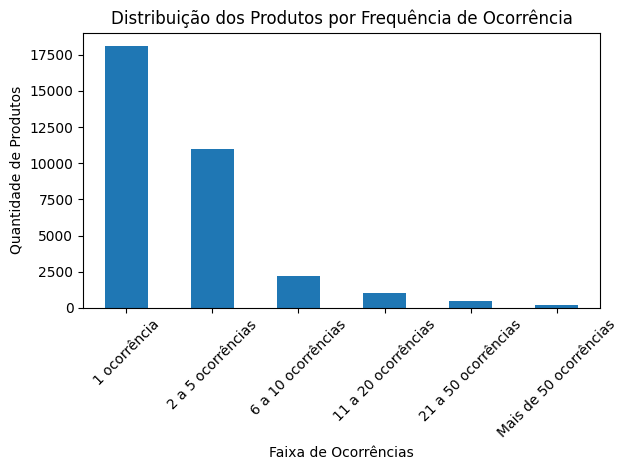

In [10]:
# Construindo o gráfico de barras com as faixas de ocorrências


# Definindo as faixas de ocorrência

faixas = pd.cut(
    frequencia_produtos['count'],
    bins=[0, 1, 5, 10, 20, 50, float('inf')],
    labels=[
        '1 ocorrência',
        '2 a 5 ocorrências',
        '6 a 10 ocorrências',
        '11 a 20 ocorrências',
        '21 a 50 ocorrências',
        'Mais de 50 ocorrências'
    ]
)

distribuicao_faixas = faixas.value_counts().sort_index()

print(distribuicao_faixas)
print("\n")

distribuicao_faixas.plot(kind='bar')

plt.title('Distribuição dos Produtos por Frequência de Ocorrência')
plt.xlabel('Faixa de Ocorrências')
plt.ylabel('Quantidade de Produtos')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 4.1 Síntese da análise exploratória

**Síntese:**

- Foi possível observar que 25% dos itens aparecem em mais de 3 pedidos.

- Média > mediana = forte indicador de distribuição assimétrica.

- Existe um grupo seleto de produtos com frequencia de ocorrência muito superior aos demais.

- Observou-se uma elevada dispersão das vendas entre os produtos do catálogo. Dos 32.951 produtos presentes na base, 18.117 (aproximadamente 55%) apareceram apenas 1 vez durante todo o período analisado, ou seja, tiveram taxa de ocorrência de apenas 1 pedido). Esse comportamento indica uma forte presença de produtos de baixa recorrência, característica comum em operações de e-commerce com amplo sortimento.

- Dado o ponto acima, é esperado que as relações de compra conjunta relevantes estejam concentradas em um subconjunto reduzido de produtos que possuam maior frequência de ocorrência nos pedidos.


# 5. Preparação dos dados + Pré- Processamento


In [11]:
print("Tipo de problema: Clusterização")
print("Target: Não possui")
print("Número de features: 3")
print("Features: 'order_id', 'product_id' e 'product_category_name'")

Tipo de problema: Clusterização
Target: Não possui
Número de features: 3
Features: 'order_id', 'product_id' e 'product_category_name'


In [12]:
# Para dar continuidade às manipulações dos dados, será preciso realizar o merge para chegar na tabela que contenha o ID do pedido, ID item e categoria.

# Merge

order_items_categoria = order_items.merge(products[['product_id', 'product_category_name']], on='product_id',how='left')
print("Nova tabela, após o merge")
display(order_items_categoria.head())
print("\n")

# Verificando a quantidade de linhas na nova tabela

resumo_shape = pd.DataFrame({'Métrica': ['Quantidade de linhas',
                            'Quantidade de colunas'],
                             'Valor': [order_items_categoria.shape[0],
                                       order_items_categoria.shape[1]]})

print("Resumo da nova tabela")
display(resumo_shape)
print("\n")

print("Resumo da tabela order_items")
display(order_items.shape)
print("\n")

# Verificando quantas linhas estão sem categoria

linha_sem_categoria = order_items_categoria['product_category_name'].isna().sum()
print(f"Foi verificado que {linha_sem_categoria} linhas estão sem categoria")
print("\n")

# Verificando quantos produtos estão sem categoria

sem_categoria =order_items_categoria[order_items_categoria['product_category_name'].isna()]['product_id'].nunique()

print(f"Identificou-se que {sem_categoria} itens estão sem categoria")


Nova tabela, após o merge


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim




Resumo da nova tabela


,Métrica,Valor
0,Quantidade de linhas,112650
1,Quantidade de colunas,8




Resumo da tabela order_items


(112650, 7)



Foi verificado que 1603 linhas estão sem categoria


Identificou-se que 610 itens estão sem categoria


- Foram identificados 1.603 registros (1,42% da base) sem informação de categoria do produto. Como o objetivo principal do trabalho é analisar padrões de compra conjunta entre produtos, optou-se por manter esses registros e substituir os valores ausentes pela categoria "Sem Categoria", preservando todas as informações transacionais para as etapas posteriores de modelagem.

In [13]:
# Preenchendo as células vazias da coluna de categoria

order_items_categoria['product_category_name'] = (
    order_items_categoria['product_category_name']
    .fillna('Sem Categoria')
)
print("Itens sem categoria:",order_items_categoria['product_category_name'].isna().sum())

Itens sem categoria: 0


# 5.0.1 Análise de Distribuição de Categorias

Como agora temos o merge, podemos estudar o comportamento das categorias. A análise será análoga à realizada com os produtos na análise exploratória.

In [14]:
# Criando tabela de frequência

frequencia_categorias = (
    order_items_categoria['product_category_name']
    .value_counts()
    .reset_index()
)

frequencia_categorias.columns = [
    'product_category_name',
    'count'
]

display(frequencia_categorias.head(20))

,product_category_name,count
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


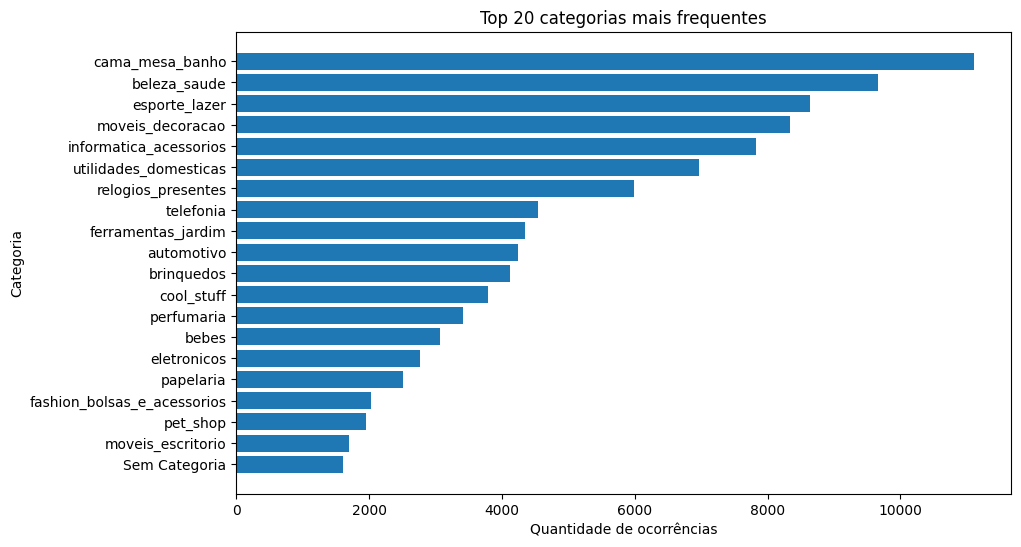

In [15]:
# Gerando gráfico de categorias

top20_cat = frequencia_categorias.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20_cat['product_category_name'],
    top20_cat['count']
)

plt.xlabel('Quantidade de ocorrências')
plt.ylabel('Categoria')
plt.title('Top 20 categorias mais frequentes')

plt.gca().invert_yaxis()

plt.show()


In [16]:
# Analisando os dados sobre as categorias:

frequencia_categorias['count'].describe()

,count
count,74.000000
mean,1522.297297
std,2564.979835
min,2.000000
25%,77.750000
50%,279.500000
75%,1669.000000
max,11115.000000


# 5.0.2 Síntese da Análise de Categorias

- A análise descritiva das categorias mostra uma distribuição assimétrica forte. Embora a média de ocorrências por categoria seja próxima de 1.522 registros, a mediana é de apenas 280 ocorrências, o que indica que poucas categorias concentram grande parte dos produtos vendidos. Adicionalmente, observou-se a existência de uma cauda longa de categorias com baixa frequência, característica comum em marketplaces com amplo portfólio de produtos.

# 5.0.3 Ajuste de Pedidos

- Relembrando que o objetivo do presente trabalho é analisar casos de compra conjunta de itens e sua frequência, pedidos com apenas 1 item em sua composição não agregam valor nas análises. Desta forma, esses casos serão removidos da base de dados.

In [17]:
# Identificando quantos itens cada pedido possui

itens_por_pedido = (
    order_items_categoria
    .groupby('order_id')['product_id']
    .nunique()
    .reset_index()
)

itens_por_pedido.columns = [
    'order_id',
    'qtd_produtos'
]

display(itens_por_pedido.head())
print("\n")

# Entendendo a distribuição

itens_por_pedido['qtd_produtos'].describe()
print("\n")

print("Tabela quantidade de produtos x pedidos",itens_por_pedido['qtd_produtos'].value_counts().sort_index())
print("\n")

# Verificando quantas linhas restarão após o filtro dos pedidos

pedidos_validos = itens_por_pedido[itens_por_pedido['qtd_produtos'] >= 2]['order_id']

base_filtrada = order_items_categoria[order_items_categoria['order_id'].isin(pedidos_validos)]

base_filtrada.shape
print("\n")

# Resumo dos pedidos e da transformação

print("Resumo dos pedidos e da transformação que será realizada")
print("\n")

resumo_filtro = pd.DataFrame({
    'Métrica': [
        'Pedidos totais',
        'Pedidos com 1 produto',
        'Pedidos com 2 ou mais produtos',
        'Registros antes do filtro',
        'Registros após o filtro'
    ],
    'Valor': [
        itens_por_pedido.shape[0],
        (itens_por_pedido['qtd_produtos'] == 1).sum(),
        (itens_por_pedido['qtd_produtos'] >= 2).sum(),
        order_items_categoria.shape[0],
        base_filtrada.shape[0]
    ]
})

display(resumo_filtro)
print("\n")

print("Produtos únicos na base filtrada:", base_filtrada['product_id'].nunique())
print("\n")

print("Categorias únicas na base filtrada:", base_filtrada['product_category_name'].nunique())
print("\n")


,order_id,qtd_produtos
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1






Tabela quantidade de produtos x pedidos qtd_produtos
1    95430
2     2846
3      298
4       70
5        8
6       10
7        3
8        1
Name: count, dtype: int64




Resumo dos pedidos e da transformação que será realizada




,Métrica,Valor
0,Pedidos totais,98666
1,Pedidos com 1 produto,95430
2,Pedidos com 2 ou mais produtos,3236
3,Registros antes do filtro,112650
4,Registros após o filtro,7768




Produtos únicos na base filtrada: 4885


Categorias únicas na base filtrada: 67




In [18]:
# Filtrando itens com menor taxa de ocorrência

frequencia_produtos_filtrada = (
    base_filtrada['product_id']
    .value_counts()
    .reset_index()
)

frequencia_produtos_filtrada.columns = [
    'product_id',
    'count'
]

print("Descritivo Frequência_produtos",frequencia_produtos_filtrada['count'].describe())
print("\n")


print("Itens com frequencia = 1: ",(frequencia_produtos_filtrada['count'] == 1).sum())
print("\n")

print("Itens com frequencia <= 2: ",(frequencia_produtos_filtrada['count'] <= 2).sum())
print("\n")

print("Itens com frequencia <= 5: ",(frequencia_produtos_filtrada['count'] <= 5).sum())
print("\n")

print("Itens com frequencia <= 10: ",(frequencia_produtos_filtrada['count'] <= 10).sum())
print("\n")

Descritivo Frequência_produtos count    4885.000000
mean        1.590174
std         2.207385
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        53.000000
Name: count, dtype: float64


Itens com frequencia = 1:  3670


Itens com frequencia <= 2:  4369


Itens com frequencia <= 5:  4759


Itens com frequencia <= 10:  4861




In [19]:
# Criando uma nova base contendo produtos com frequência >= 2

produtos_validos = frequencia_produtos_filtrada[
    frequencia_produtos_filtrada['count'] >= 2
]['product_id']

base_final = base_filtrada[
    base_filtrada['product_id'].isin(produtos_validos)
]

print("Composição da nova base: ",base_final.shape)
print("\n")

print("Produtos únicos da nova base: ", base_final['product_id'].nunique())
print("\n")

# Ententendo o impacto da retirada dos produtos com frequência = 1 nos demais pedidos (exemplo: pedido continha 2 itens e 1 deles foi removido, logo ele passou a ter apenas 1 item na composição, o que não é interessante )

itens_por_pedido_final = (
    base_final
    .groupby('order_id')['product_id']
    .nunique()
    .reset_index()
)

itens_por_pedido_final.columns = [
    'order_id',
    'qtd_produtos'
]


print("Quantidade de Itens x quantidade de pedidos:")
print("\n")
print(itens_por_pedido_final['qtd_produtos'].value_counts().sort_index())
print("\n")

print("Quantidade de pedidos antes de remover os pedidos com apenas 1 item: ", base_final['order_id'].nunique())
print("\n")

# Tivemos 989 pedidos com apenas 1 item em sua composição criados e que precisarão ser retirados da base.

# Identificando pedidos válidos

pedidos_validos_final = itens_por_pedido_final[
    itens_por_pedido_final['qtd_produtos'] >= 2
]['order_id']

# Filtrando a base

base_coocorrencia = base_final[
    base_final['order_id'].isin(pedidos_validos_final)
]

# Validando resultado

print("Registros:", base_coocorrencia.shape[0])
print("Colunas:", base_coocorrencia.shape[1])

print("Pedidos únicos:",
      base_coocorrencia['order_id'].nunique())

print("Produtos únicos:",
      base_coocorrencia['product_id'].nunique())
print("\n")


# Verificando se sobrou algum pedido com apenas 1 item na composição

print("Nova relação de pedidos vs quantidade de itens nele")

(
base_coocorrencia
    .groupby('order_id')['product_id']
    .nunique()
    .value_counts()
    .sort_index()

)




Composição da nova base:  (4098, 8)


Produtos únicos da nova base:  1215


Quantidade de Itens x quantidade de pedidos:


qtd_produtos
1     989
2    1016
3      78
4      11
5       4
6       1
Name: count, dtype: int64


Quantidade de pedidos antes de remover os pedidos com apenas 1 item:  2099


Registros: 2860
Colunas: 8
Pedidos únicos: 1110
Produtos únicos: 929


Nova relação de pedidos vs quantidade de itens nele


,count
product_id,
2,1016
3,78
4,11
5,4
6,1


Shape: (2860, 8)
Pedidos únicos: 1110
Produtos únicos: 929


,produto_1,produto_2,coocorrencia
710,05b515fdc76e888aada3c6d66c201dff,270516a3f41dc035aa87d220228f844c,100
45,36f60d45225e60c7da4558b070ce4b60,e53e557d5a159f5aa2c5e995dfdf244b,48
709,05b515fdc76e888aada3c6d66c201dff,05b515fdc76e888aada3c6d66c201dff,45
711,270516a3f41dc035aa87d220228f844c,270516a3f41dc035aa87d220228f844c,45
950,710b7c26b7a742f497bba45fab91a25f,a9d9db064d4afd4458eb3e139fe29167,36
887,62995b7e571f5760017991632bbfd311,ac1ad58efc1ebf66bfadc09f29bdedc0,36
263,35afc973633aaeb6b877ff57b2793310,99a4788cb24856965c36a24e339b6058,30
621,308e4e21ae228a10f6370a243ae59995,90b58782fdd04cb829667fcc41fb65f5,30
692,2ef36e1cae01b86d0ff0a2f50ff2bd53,53759a2ecddad2bb87a079a1f1519f73,30
175,18486698933fbb64af6c0a255f7dd64c,dbb67791e405873b259e4656bf971246,26


,coocorrencia
count,1230.000000
mean,2.742276
std,5.035537
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,100.000000


<Axes: ylabel='Frequency'>

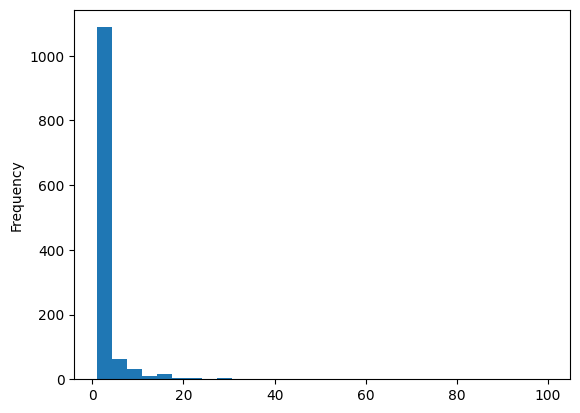

In [20]:
# Analisando a estrutura da base final

print("Shape:", base_coocorrencia.shape)

print("Pedidos únicos:",
      base_coocorrencia['order_id'].nunique())

print("Produtos únicos:",
      base_coocorrencia['product_id'].nunique())

# Agora, será preciso criar uma nova base voltada para a coocorrência entre os itens

# Reorganizando o formato da base final (coocorrência) em lista

produtos_por_pedido = (
    base_coocorrencia
    .groupby('order_id')['product_id']
    .apply(list)
)

# Mapeando as coocorrências

pares = Counter()

for produtos in produtos_por_pedido:
    if len(produtos) > 1:
        for par in combinations(sorted(produtos), 2):
            pares[par] += 1

# Criando base de coocorrência

coocorrencia_df = pd.DataFrame(
    [(p1, p2, count) for (p1, p2), count in pares.items()],
    columns=["produto_1", "produto_2", "coocorrencia"]
)

# Top 10 coocorrências

display(coocorrencia_df.sort_values('coocorrencia', ascending=False).head(10))
print("\n")

# Entendendo a distribuição da coocorência

display (coocorrencia_df['coocorrencia'].describe())

coocorrencia_df['coocorrencia'].plot(kind='hist', bins=30)

In [21]:
# Por fim, será criada a matriz produto x produto

matriz = coocorrencia_df.pivot_table(
    index='produto_1',
    columns='produto_2',
    values='coocorrencia',
    fill_value=0
)

matriz = matriz.add(matriz.T, fill_value=0)

# Retirando valores "NaN" + transformando os dados para inteiros

matriz = matriz.fillna(0)
matriz = matriz.astype(int)


matriz.head()

,005030ef108f58b46b78116f754d8d38,00ba6d766f0b1d7b78a5ce3e1e033263,0129d1e9b29d3fe6833cc922374cd252,013ee64977aaa6b2b25475095162e0e9,014a8a503291921f7b004a5215bb3c36,0152f69b6cf919bcdaf117aa8c43e5a2,017692475c1c954ff597feda05131d73,01ef0716b68c8493434ad32430c24e18,01ff1ff8aa5dec93e9938b989393a4ca,02475368dfb38934fe55f574024fe1d7,...,fe59a1e006df3ac42bf0ceb876d70969,fe6f03cedd96bcbc5c8726c5963fd35c,feb4ade62e32b8d74c6f69f635057964,ff29d8cb1cd0cd5ea37b80dac9939e1c,ff2c1ec09b1bb340e84f0d6b21cc7dbb,ff6caf9340512b8bf6d2a2a6df032cfa,ff7a70b3356d433014b7d6957ed196cb,ff9032482857269e8683f0c2f8ba4709,ff95ac47246ef13e48712ea1ff8df0d9,ffe8083298f95571b4a66bfbc1c05524
005030ef108f58b46b78116f754d8d38,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00ba6d766f0b1d7b78a5ce3e1e033263,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,4,0
0129d1e9b29d3fe6833cc922374cd252,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
013ee64977aaa6b2b25475095162e0e9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
014a8a503291921f7b004a5215bb3c36,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5.1 Justificativas das manipulações e dos pré-processamentos

- Foi realizado o merge para chegar a uma base de estudo consolidada, contendo as informações de identificação dos pedidos, identificação dos produtos e suas respectivas categorias.

- Observou-se 610 itens e 1603 linhas sem categoria. Como o intuito da análise é identificar padrões de compra conjunta entre itens e entre categorias também, para não perder informação sobre esses itens, optou-se por atribuir o valor "Sem categoria" a eles.

- Para estudar a ocorrência conjunta dos produtos é preciso ter ao menos 2 itens no pedido. Desta forma, casos com apenas 1 item na composição não são interessantes e precisaram ser retirados da base.



Tabela pós merge + filtro de pedidos:

- Para analisar a ocorrência conjunta entre os itens, foi criada uma matriz produto x produto, porém como temos 4.885 produtos únicos, a matriz resultante teria 23.863.225 células, o que é uma quantidade elevada de informação para o modelo processar. Assim, foi necessário filtrar os produtos com menor frequência de ocorrência nos pedidos para seguir com sua retirada da base. A exclusão também auxilia no ajuste de possíveis outliers.

- A análise de frequência revelou que aproximadamente 75% dos produtos apareciam apenas uma vez nos pedidos com múltiplos itens. Como produtos extremamente raros contribuem pouco para a identificação de padrões recorrentes de compra conjunta, optou-se por manter apenas produtos presentes em pelo menos 2 pedidos, reduzindo ruídos e tornando a matriz de coocorrência mais representativa.

- Após a remoção dos produtos com frequência igual a 1, identificou-se que 989 pedidos passaram a conter apenas um produto em sua composição pois com a exclusão dos itens de baixa frequência, pedidos que antes possuíam 2 items ficaram com apenas 1. Desta forma, foi preciso realizar um novo filtro para retirar esses pedidos, com apeans 1 item em sua composição, da base. Resultando no cenário abaixo:



| Etapa                                     | Registros |   Pedidos | Produtos |
| ----------------------------------------- | --------: | --------: | -------: |
| Base original                             |   112.650 |   98.667  |   32.951 |
| Após remover pedidos com 1 item           |     7.768 |     3.236 |    4.885 |
| Após remover produtos com frequência = 1  |     4.098 |     2.099 |    1.215 |
| Após remover os novos pedidos com 1 item  | **2.860** | **1.110** |  **929** |


 Base final de registros + construção de tabela de coocorrência:

- A base final utilizada na modelagem contém 2.860 registros, distribuídos em 1.110 pedidos e 929 produtos distintos. Essa base servirá de entrada para a construção da matriz de coocorrência produto × produto , que será utilizada na fase de clusterização.

- A partir da análise da base de coocorência foi visto que a maioria dos pares de produtos apresenta baixa frequência de coocorrência, com mediana igual a 1 e 75% dos pares aparecendo no máximo 2 vezes. Esse comportamento indica uma estrutura de “cauda longa”, onde grande parte das combinações ocorre de forma esporádica.

- Ainda sobre coocorência, foi possível observar a existência de um pequeno conjunto de pares com alta coocorrência, sugerindo relações fortes entre determinados produtos. Esses pares representam padrões recorrentes de compra conjunta e tendem a ter maior relevância para a formação dos clusters. Isso reforça a hipótese de que um pequeno grupo de produtos representa a maior parte das relações de pedidos de compra em conjunto.

- Após o pré-processamento, o conjunto de dados resultou em aproximadamente 929 produtos únicos, organizados em uma matriz de coocorrência produto × produto com cerca de 863 mil relações possíveis.

# 6. Baseline e modelos candidatos


In [22]:
# BASELINE: Agrupamento por categoria

baseline = products[
    ["product_id", "product_category_name"]
].copy()

# Cada categoria corresponde a um cluster

baseline["cluster"] = (
    baseline["product_category_name"]
    .astype("category")
    .cat.codes
)


# Ajustando matriz em lista de arestas para o candidato 1 trabalhar (Preparação para modelo Louvain)

edges = matriz.stack().reset_index()
edges.columns = ["produto_1", "produto_2", "weight"]

# Removendo duplicatas e auto-links

edges = edges[edges["weight"] > 0]
edges = edges[edges["produto_1"] != edges["produto_2"]]

# Filtrando ruídos para ter menos distorções na visualização

edges = edges[edges["weight"] >= 2]

# Configurando Louvain (CANDIDATO 1)

G = nx.from_pandas_edgelist(
    edges,
    source="produto_1",
    target="produto_2",
    edge_attr="weight"
)
# Configurando Spetral Clustering (CANDIDATO 2)

X = matriz.values

S = X / X.max()

## 6.1 Justificativa dos modelos

- Diferentemente de bases tabulares tradicionais, onde cada observação é descrita por um conjunto de atributos independentes, aqui, os dados representam relações entre produtos, podendo ser interpretados como uma rede de conexões formada pelas compras realizadas pelos clientes. Por isso, optou-se por utilizar algoritmos capazes de explorar diretamente essa estrutura relacional.

- O modelo baseline escolhido foi o agrupamento por categoria do produto. Essa abordagem representa uma estratégia simples e amplamente utilizada no varejo, baseada na premissa de que produtos da mesma categoria tendem a ser comprados em conjunto. Embora seja facilmente interpretável e operacionalmente simples, ela não considera o comportamento real dos consumidores nem identifica relações de compra entre produtos de categorias distintas. Dessa forma, serve como referência para avaliar o ganho proporcionado pelos modelos baseados em coocorrência.

- O Louvain foi escolhido como modelo candidato 1 por ser um dos algoritmos mais utilizados para identificação de comunidades em grafos, ele atua na identificação de grupos de nós mais conectados entre si do que com o restante da rede, característica alinhada ao objetivo de descobrir conjuntos de produtos frequentemente adquiridos em conjunto. Além disso, o método não requer etapas adicionais de transformação ou criação de variáveis, trabalhando diretamente sobre a estrutura de conexões da rede.

- Como modelo candidato 2 foi utilizado o Spectral Clustering, uma abordagem que também pode ser aplicada a dados relacionais. O algoritmo utiliza a matriz de similaridade entre os produtos para gerar uma representação espectral dos dados e, a partir dela, identificar agrupamentos. Dessa forma, o Spectral Clustering permite avaliar se uma abordagem baseada em similaridade produz resultados competitivos em comparação à detecção de comunidades realizada pelo Louvain.

- Os modelos clássicos de clusterização estudados, como K-Means e Clusterização Hierárquica, são tradicionalmente mais adequados para bases tabulares em que cada observação é representada por atributos numéricos em um espaço vetorial. Como o problema deste projeto está centrado na análise de relações de coocorrência entre produtos, optou-se por priorizar métodos capazes de explorar explicitamente a estrutura de rede presente nos dados.

# 8. Treinamento e avaliação inicial


In [23]:
results = {}
trained_models = {}

# Modelo Baseline

t0 = time.time()

baseline_clusters = baseline["cluster"].nunique()

# Entendendo a pureza das categorias (Baseline)

baseline_purity = (
    baseline
    .groupby("cluster")["product_category_name"]
    .apply(lambda x: x.value_counts(normalize=True).max())
    .mean()
)

results["Baseline"] = {
    "n_clusters": baseline_clusters,
    "purity": baseline_purity,
    "train_time_s": round(time.time() - t0, 4)
}

trained_models["Baseline"] = baseline


# Modelo Louvain (candidato 1)

t0 = time.time()

communities = louvain_communities(G, weight="weight", seed=42)

cluster_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        cluster_map[node] = i

clusters_louvain = pd.DataFrame.from_dict(
    cluster_map,
    orient="index",
    columns=["cluster"]
).reset_index().rename(columns={"index": "product_id"})

mod = nx.algorithms.community.quality.modularity(
    G,
    communities,
    weight="weight"
)

results["Louvain"] = {
    "n_clusters": len(communities),
    "modularity": mod,
    "train_time_s": round(time.time() - t0, 4)
}

trained_models["Louvain"] = communities

# Modelo Spectral (candidato 2)

t0 = time.time()

spectral = SpectralClustering(
    n_clusters=5,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=42
)
labels_spec = spectral.fit_predict(S)

np.fill_diagonal(S, 1)

dist = 1 - S

np.fill_diagonal(dist, 0)

sil = silhouette_score(
    dist,
    labels_spec,
    metric="precomputed"
)

clusters_spectral = pd.DataFrame({
    "product_id": matriz.index.astype(str),
    "cluster": labels_spec
})

clusters_spectral = clusters_spectral.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

results["Spectral"] = {
    "n_clusters": len(set(labels_spec)),
    "silhouette": sil,
    "train_time_s": round(time.time() - t0, 4)
}

trained_models["Spectral"] = spectral

# Resultados

results_df = pd.DataFrame(results).T.sort_values(
    by=[col for col in ["modularity", "silhouette"] if col in pd.DataFrame(results).columns],
    ascending=False
)

In [24]:
# Entendendo a pureza das categorias (Louvain)

df_louvain = clusters_louvain.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

purity_louvain = (
    df_louvain.groupby("cluster")["product_category_name"]
    .apply(lambda x: x.value_counts(normalize=True).max())
    .mean()
)

# Entendendo a pureza das categorias (Spectral)

purity_spectral = (
    clusters_spectral.groupby("cluster")["product_category_name"]
    .apply(lambda x: x.value_counts(normalize=True).max())
    .mean()
)

# Resultados consolidados

results["Louvain"]["purity"] = purity_louvain
results["Spectral"]["purity"] = purity_spectral

results_df = pd.DataFrame(results).T

results_df



,n_clusters,purity,train_time_s,modularity,silhouette
Baseline,74.0,1.000000,0.1260,NaN,NaN
Louvain,224.0,0.924119,0.1208,0.978385,NaN
Spectral,5.0,0.220978,1.0147,NaN,0.0002


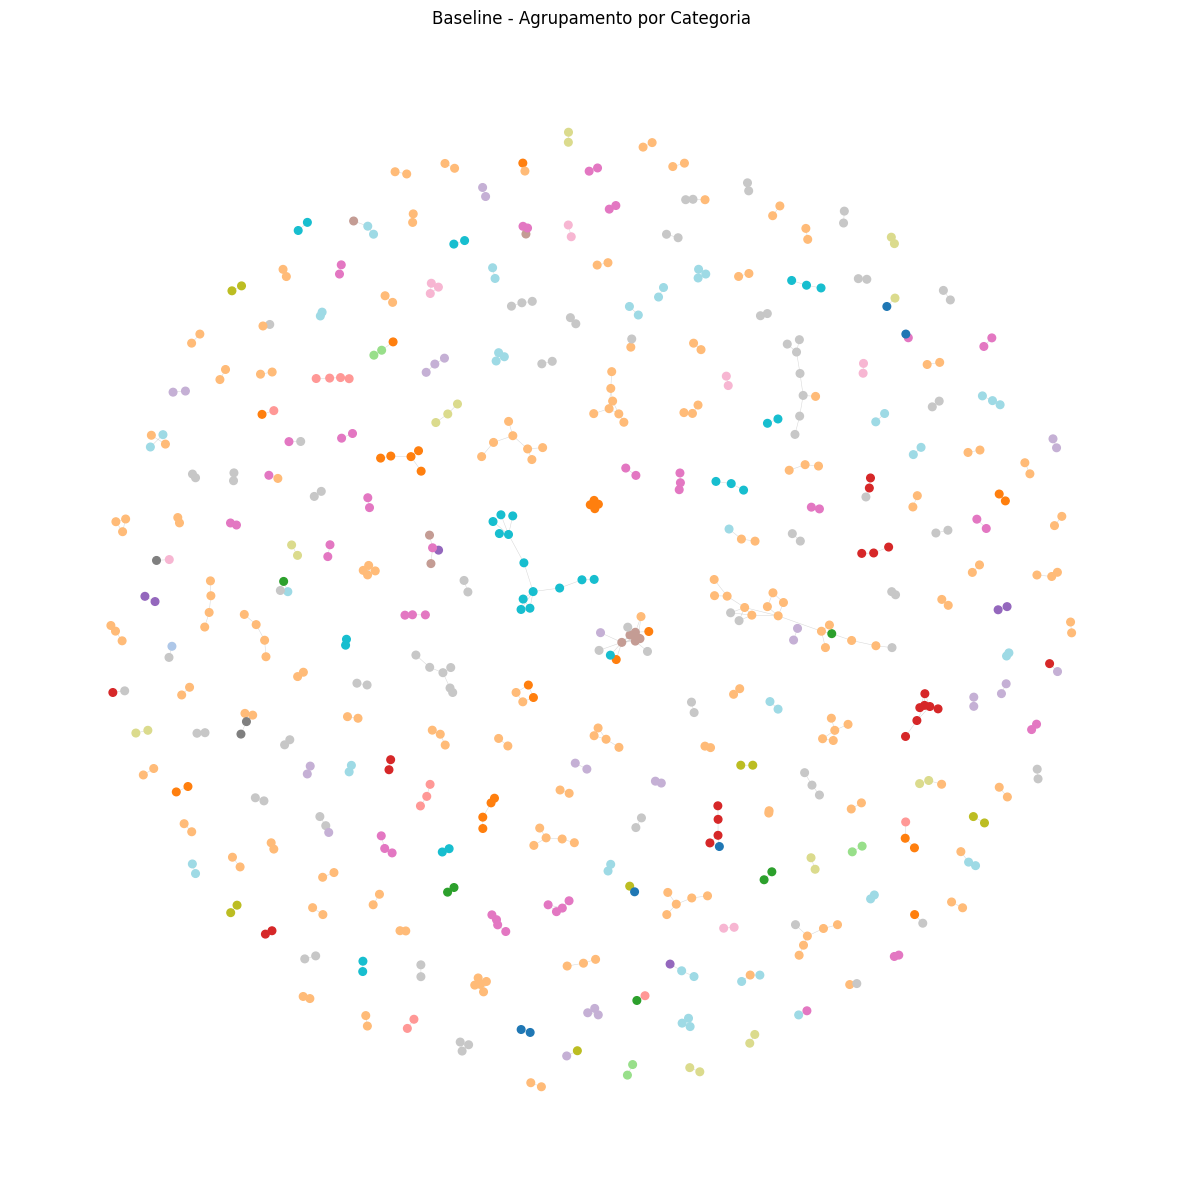

In [25]:
# Visualizando os grafos (Baseline)

plt.figure(figsize=(15, 15))

# posição dos nós
pos = nx.spring_layout(G, seed=42)

# Mapeando cluster para cada produto
cluster_map = dict(zip(
    baseline["product_id"],
    baseline["cluster"]
))

# Cor dos nós
node_colors = [
    cluster_map.get(node, -1)
    for node in G.nodes()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=30,
    node_color=node_colors,
    cmap=plt.cm.tab20
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.15,
    width=0.4
)

plt.title("Baseline - Agrupamento por Categoria")
plt.axis("off")
plt.show()

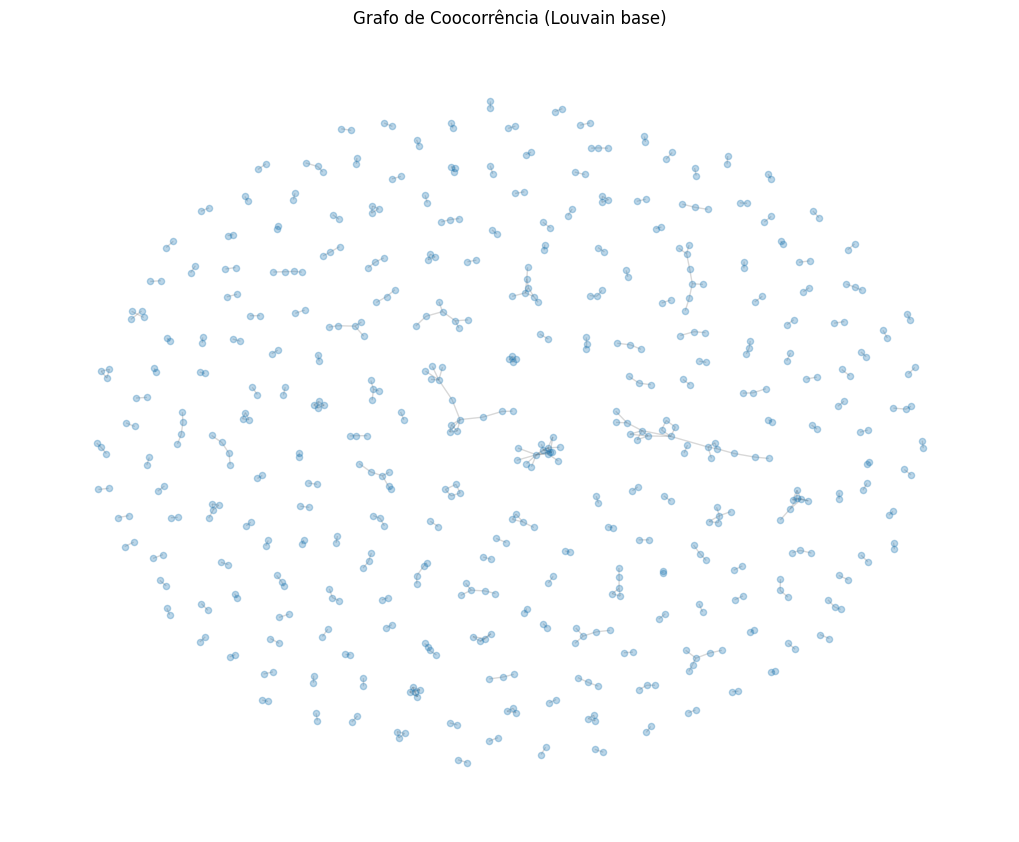

In [26]:
# Visualizando os grafos (Louvain)

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_size=20,
    edge_color="gray",
    alpha=0.3
)

plt.title("Grafo de Coocorrência (Louvain base)")
plt.show()

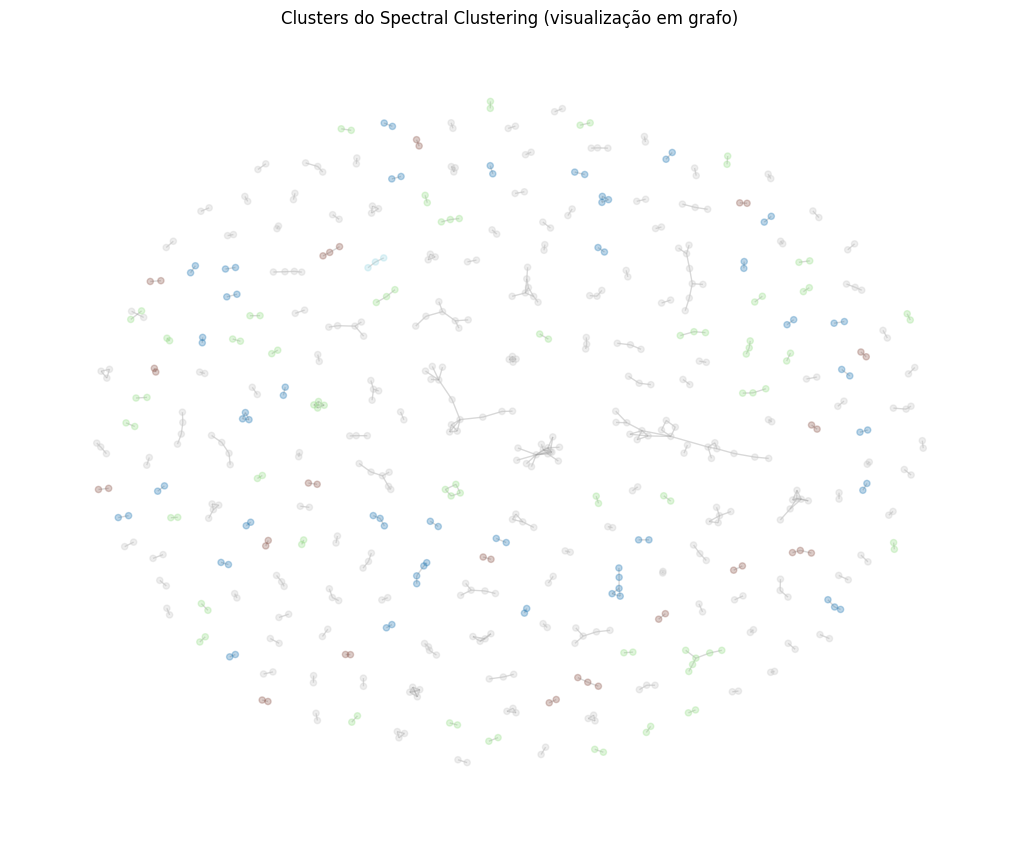

In [27]:
# Visualizando os clusters (Spectral)

# 1. Criando dataframe de clusters

clusters_spectral = pd.DataFrame({
    "product_id": matriz.index.astype(str),
    "cluster": labels_spec
})

# 2. Mapeando produto → cluster

node_to_cluster = dict(zip(
    clusters_spectral["product_id"],
    clusters_spectral["cluster"]
))

# 3. Adicionando cores

colors = [node_to_cluster.get(node, -1) for node in G.nodes()]

# 4. Layout (mesmo do Louvain)
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))

nx.draw(
    G,
    pos,
    node_color=colors,
    cmap=plt.cm.tab20,
    node_size=20,
    edge_color="gray",
    alpha=0.3
)

plt.title("Clusters do Spectral Clustering (visualização em grafo)")
plt.show()

## 8.1 Análise dos resultados iniciais

O modelo superou o baseline?

- É possível dizer que os modelos candidatos superam o baseline pelo fato de levarem em consideração o peso das ocorrências conjuntas dos itens, ou seja, eles atribuem valores maiores para as relações mais frequentes, o que vai de encontro com o ponto focal do projeto. Dentre os modelos, Louvain se destacou pela modularidade  alta (0.978), pureza elevada (0.92)  e 224 comunidades bem definidas. Já o spectral teve um silhouette consideravelmente baixo (0.00018) e pureza das categorias de (0.23).

A métrica escolhida é suficiente para avaliar o problema?

- Não, sozinha ela ainda não avalia devidamente o caso pois como estão sendo analisados 2 "mundos" ( grafo - Louvain e vetorial - Spectral), é necessário utilizar ao menos 2 métricas para avaliá-los. Além disso é interessante explorar mais métricas devido a restrição prática da interpretabilidade.

Algum modelo parece sofrer de underfitting?

- O Spectral, pois apresentou clusters pouco significativos e não conseguiu identificar as estruturas dos dados suficientemente.

O tempo de treinamento é aceitável?

- Sim, o treinamento durou menos de 1 segundo. Considerando o tamanho da matriz de coocorrência e a quantidade de produtos analisados, o desempenho computacional foi positivo, não representando uma limitação para a aplicação proposta.

O resultado faz sentido considerando a EDA?

- A análise exploratória indicou que as relações de compra conjunta estariam concentradas em um número reduzido de produtos frequentes. Os resultados da clusterização confirmaram essa hipótese, destacando uma estrutura de rede composta por diversas comunidades menores e bem definidas, ponto que se relaciona diretamente com a alta dispersão observada na frequência de ocorrência dos produtos.

# 9. Validação e otimização de hiperparâmetros

Qual modelo foi otimizado?

- Tentou-se otimizar ambos os modelos candidatos, porém apenas o Spectral apresentou uma melhora perceptível.

Quais hiperparâmetros foram testados:

- Peso das arestas (Louvain), k e threshfold (Spectral)

Qual estratégia de validação foi usada?

- Foi utilizada uma estratégia de comparação entre modelos candidatos, avaliando os agrupamentos gerados por Louvain (candidato 1) e Spectral Clustering (candidato 2). Além disso, foram realizados testes de hiperparâmetros para verificar a estabilidade e a qualidade dos clusters obtidos.

Qual métrica guiou a escolha?

- A escolha foi guiada principalmente pela modularidade para o Louvain, por ser uma métrica adequada para avaliar comunidades em grafos de coocorrência. Como métrica complementar, foi utilizada a pureza das categorias para verificar a coerência dos agrupamentos do ponto de vista de negócio. No Spectral Clustering também foi avaliado o Silhouette Score + pureza das categorias, mas os resultados permaneceram próximos de zero (silhouette), indicando baixa separação entre os clusters.

Qual foi a melhor configuração?

- **Louvain**: *min_weight* = 2

- **Spectral Clustering** = *Threshold* = 0.2 / *n_clusters (k)* = 15 / *affinity* = 'precomputed' / *assign_labels* = 'kmeans' / *random_state* = 42

In [28]:
# Ajustando peso das arestas (Louvain)

results_louvain = []

for w in [1, 2, 3, 4]:

    # 1. filtrando arestas

    edges_temp = edges[edges["weight"] >= w]

    # 2. reconstrindo grafo

    G_temp = nx.from_pandas_edgelist(
        edges_temp,
        source="produto_1",
        target="produto_2",
        edge_attr="weight"
    )

    # 3. Rodando Louvain

    t0 = time.time()

    communities = louvain_communities(
        G_temp,
        weight="weight",
        seed=42
    )

    # 4. Modularidade

    mod = nx.algorithms.community.quality.modularity(
        G_temp,
        communities,
        weight="weight"
    )

    # 5. Número de clusters

    n_clusters = len(communities)

    results_louvain.append({
        "min_weight": w,
        "modularity": mod,
        "n_clusters": n_clusters,
        "time_s": round(time.time() - t0, 4)
    })

    # Resultados (Louvain)

    results_louvain_df = pd.DataFrame(results_louvain)

    display(results_louvain_df)

    # Peso 2 se apresentou o melhor por ter a maior modularidade, estrutura mais rica (224 comunidades) e não removeu relações importantes.


,min_weight,modularity,n_clusters,time_s
0,1,0.978385,224,0.0574


,min_weight,modularity,n_clusters,time_s
0,1,0.978385,224,0.0574
1,2,0.978385,224,0.0530


,min_weight,modularity,n_clusters,time_s
0,1,0.978385,224,0.0574
1,2,0.978385,224,0.0530
2,3,0.971114,124,0.0236


,min_weight,modularity,n_clusters,time_s
0,1,0.978385,224,0.0574
1,2,0.978385,224,0.0530
2,3,0.971114,124,0.0236
3,4,0.968869,107,0.0217


In [29]:
# Ajustando k + thresholds (Spectral)

results_spectral = []

k_values = [3, 5, 8, 10, 15]
thresholds = [0.0, 0.1, 0.2, 0.3]

for t in thresholds:

    # 1. Criando matrizes de similaridade filtrada

    S_temp = S.copy()
    S_temp[S_temp < t] = 0

    # Garantindo diagonal válida

    np.fill_diagonal(S_temp, 1)

    for k in k_values:

        t0 = time.time()

        model = SpectralClustering(
            n_clusters=k,
            affinity='precomputed',
            assign_labels='kmeans',
            random_state=42
        )

        labels = model.fit_predict(S_temp)

        # Distância para silhouette

        dist = 1 - S_temp
        np.fill_diagonal(dist, 0)

        # Métrica principal

        sil = silhouette_score(
            dist,
            labels,
            metric="precomputed"
        )

        # Pureza das categorias

        clusters_tmp = pd.DataFrame({
            "product_id": matriz.index.astype(str),
            "cluster": labels
        }).merge(
            products[['product_id', 'product_category_name']],
            on='product_id',
            how='left'
        )

        purity = (
            clusters_tmp.groupby("cluster")["product_category_name"]
            .apply(lambda x: x.value_counts(normalize=True).max())
            .mean()
        )

        results_spectral.append({
            "threshold": t,
            "k": k,
            "silhouette": sil,
            "purity": purity,
            "n_clusters": len(set(labels)),
            "time_s": round(time.time() - t0, 4)
        })

# Resultados

results_spectral_df = pd.DataFrame(results_spectral)

results_spectral_df.sort_values(
    by=["silhouette", "purity"],
    ascending=False
)

# Foi possível melhorar consideravelmente a pureza, contudo o silhouette permanceu bem baixo

,threshold,k,silhouette,purity,n_clusters,time_s
14,0.2,15,0.009322,0.782722,15,0.1742
17,0.3,8,0.006674,0.784814,8,0.1367
18,0.3,10,0.006674,0.680872,10,0.1462
19,0.3,15,0.006674,0.669320,15,0.1971
13,0.2,10,0.005822,0.778004,10,0.1392
9,0.1,15,0.005678,0.768706,15,0.3126
12,0.2,8,0.003946,0.847412,8,0.1434
8,0.1,10,0.003648,0.730288,10,0.3142
7,0.1,8,0.003005,0.701244,8,0.2810
16,0.3,5,0.002717,0.655338,5,0.1189


## 9.1 Discussão da otimização

- A otimização não melhorou o resultado de forma significativa. No Louvain (candidato 1) houve apenas ajuste de granularidade (sem ganho real de modularidade), e no Spectral (candidato 2) houve leve melhora de pureza, mas sem melhora em separação (silhouette ~0).

- A busca foi limitada pelo tempo principalmente pelo custo computacional do Spectral com matriz de coocorrência densa e pela necessidade de reconstruir o grafo a cada variação de threshold no Louvain.

- A escolha dos hiperparâmtros está alinhada ao modelos, peso das arestas no no Louvain controla ruído da rede, e k + threshold no Spectral controlam granularidade e densidade da matriz, sendo escolhas coerentes para o problema.


Síntese:


- Foi confirmado que o Louvain já estava modelado num estado ótimo e pronto para o problema.

- Mostrou-se que o Spectral é sensível a parâmetros, mas limitado pela natureza dos dados.

- Foi exposto que o problema é melhor representado como rede de coocorrência do que espaço vetorial.


# 10. Avaliação final no conjunto de teste
Como o problema trabalhado se encaixa dentro do aprendizado não supervisionado, não há um conjunto de teste para validar o retorno encontrado nos modelos, ainda mais considerando a limitação de qualificação, citada anteriormente. A avaliação final foi realizada utilizando métricas internas para definir a qualidade dos clusters formados.

**Métricas**

- Modularidade
- Pureza de Categorias
- Tempo de Processamento
- Silhouette Score



In [30]:
# Consolidando os resultados e evidenciando os casos de coocorência mais interessantes

# Top correlações

top_relacoes = (
    edges
    .sort_values("weight", ascending=False)
    .head(10)
)

# Olhando para as categorias das top correlações

categorias = products[
    ["product_id", "product_category_name"]
].copy()

categorias["product_id"] = categorias["product_id"].astype(str)

# Associando categoria ao produto 1

relacoes_cat = top_relacoes.merge(
    categorias,
    left_on="produto_1",
    right_on="product_id",
    how="left"
)

relacoes_cat = relacoes_cat.rename(
    columns={
        "product_category_name": "categoria_1"
    }
)

# Associando categoria ao produto 2

relacoes_cat = relacoes_cat.merge(
    categorias,
    left_on="produto_2",
    right_on="product_id",
    how="left"
)

relacoes_cat = relacoes_cat.rename(
    columns={
        "product_category_name": "categoria_2"
    }
)

# Limpando colunas extras

relacoes_cat = relacoes_cat[
    [
        "produto_1",
        "categoria_1",
        "produto_2",
        "categoria_2",
        "weight"
    ]
]

print("Top 10 relações de coocorência")
print("\n")

display(relacoes_cat)

# A hipótese de que a coocorrência é mais forte em itens da mesma categoria pode ser validada aqui.

Top 10 relações de coocorência




,produto_1,categoria_1,produto_2,categoria_2,weight
0,05b515fdc76e888aada3c6d66c201dff,beleza_saude,270516a3f41dc035aa87d220228f844c,beleza_saude,100
1,270516a3f41dc035aa87d220228f844c,beleza_saude,05b515fdc76e888aada3c6d66c201dff,beleza_saude,100
2,36f60d45225e60c7da4558b070ce4b60,informatica_acessorios,e53e557d5a159f5aa2c5e995dfdf244b,informatica_acessorios,48
3,e53e557d5a159f5aa2c5e995dfdf244b,informatica_acessorios,36f60d45225e60c7da4558b070ce4b60,informatica_acessorios,48
4,ac1ad58efc1ebf66bfadc09f29bdedc0,utilidades_domesticas,62995b7e571f5760017991632bbfd311,utilidades_domesticas,36
5,a9d9db064d4afd4458eb3e139fe29167,utilidades_domesticas,710b7c26b7a742f497bba45fab91a25f,utilidades_domesticas,36
6,62995b7e571f5760017991632bbfd311,utilidades_domesticas,ac1ad58efc1ebf66bfadc09f29bdedc0,utilidades_domesticas,36
7,710b7c26b7a742f497bba45fab91a25f,utilidades_domesticas,a9d9db064d4afd4458eb3e139fe29167,utilidades_domesticas,36
8,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,35afc973633aaeb6b877ff57b2793310,casa_conforto,30
9,90b58782fdd04cb829667fcc41fb65f5,moveis_escritorio,308e4e21ae228a10f6370a243ae59995,moveis_escritorio,30


In [31]:
# Resumo de clusters com visão às categorias

cluster_summary = (
    df_louvain
    .groupby(['cluster', 'product_category_name'])
    .size()
    .reset_index(name='count')
    .sort_values(['cluster', 'count'], ascending=[True, False])
)

display(cluster_summary)
print("\n")

# Observando os maiores clusters

cluster_sizes = (
    df_louvain['cluster']
    .value_counts()
    .reset_index()
)

cluster_sizes.columns = ['cluster', 'n_produtos']
print("\n")

display(cluster_sizes.head(10))
print("\n")
print("É possível dizer que a clusterização não criou agrupamentos muito concentrados.")

,cluster,product_category_name,count
0,0,perfumaria,3
2,1,utilidades_domesticas,2
1,1,ferramentas_jardim,1
3,2,consoles_games,2
4,3,bebes,2
...,...,...,...
266,219,utilidades_domesticas,1
267,220,consoles_games,2
268,221,cama_mesa_banho,2
269,222,beleza_saude,2


,cluster,n_produtos
0,27,14
1,28,13
2,130,11
3,194,8
4,96,7
5,104,7
6,31,7
7,76,7
8,99,6
9,125,6




É possível dizer que a clusterização não criou agrupamentos muito concentrados.


In [32]:
# Exemplos das composições dos clusters por categoria (Pelas categorias conseguimos entender se são produtos que fazem sentido num escopo maior)

# Exemplo: ferramentas_jardim e moveis_decoracao - fazem sentido dentro de um escopo de "Casa".

top_clusters = cluster_sizes.head(5)['cluster']

for c in top_clusters:

    print(f"\n===== CLUSTER {c} =====")

    display(
        cluster_summary[
            cluster_summary['cluster'] == c
        ].head(10)
    )
print("\n")
print("É possível observar que boa parte dos agrupamentos fazem sentido olhando para escopos maiores")


===== CLUSTER 27 =====


,cluster,product_category_name,count
34,27,ferramentas_jardim,6
35,27,moveis_decoracao,3
31,27,bebes,2
32,27,cama_mesa_banho,1
33,27,esporte_lazer,1
36,27,relogios_presentes,1



===== CLUSTER 28 =====


,cluster,product_category_name,count
37,28,relogios_presentes,13



===== CLUSTER 130 =====


...


===== CLUSTER 194 =====


,cluster,product_category_name,count
237,194,moveis_decoracao,7
236,194,cama_mesa_banho,1



===== CLUSTER 96 =====


,cluster,product_category_name,count
118,96,cama_mesa_banho,5
119,96,casa_conforto,1
120,96,moveis_decoracao,1




É possível observar que boa parte dos agrupamentos fazem sentido olhando para escopos maiores


## 10.1 Análise de erros e limitações

Quais tipos de erro o modelo comete mais?

- O modelo apresenta principalmente erros relacionados à criação de comunidades muito pequenas, consequência da baixa frequência de ocorrência de grande parte dos produtos da base.

Há sinais de overfitting ou underfitting?

- Não foram observados sinais de overfitting no modelo final escolhido (Louvain)

A métrica escolhida captura bem o objetivo do problema?

- A modularidade mede a qualidade da divisão de uma rede complexa em grupos ou comunidades. Considerando grafos e redes, ela quantifica o quão bem uma rede pode ser subdividida em aglomerados de nós fortemente conectados entre si. Como o objetivo é identificar a coocorência dos produtos, tendo o apoio das categorias para analisar a coerência, é possível afirmar que a modularidade captura exatamente o propósito do trabalho.


Há viés, limitação de dados ou risco de generalização?

- Como o dataset é composto pela venda de diferentes lojas com categorias distintas, a coocorrência se torna menos volumosa pois é mais difícil a venda ocorrer entre vendedores distintos quando comparada à uma única loja. Isso diminui o volume de compras com mais de 1 produto na cesta.

Em quais cenários o modelo não deveria ser usado?

- A performance / identificação de padrões será afetada proporcionalmente ao grau de diferenciação entre os itens e negócios analisados. Se forem estudados produtos / vendas de um mesmo negócio e de mesma categoria, o resultado esperado será melhor do que o visto aqui, devido a questão abordada no tópico anterior. Contudo, nada impede de extender a análise para casos de categorias distintas para buscar dinâmicas fora da curva.


# 11. Comparação final dos modelos

| Modelo                   |        Métrica principal |    Outras métricas | Tempo de treino | Observações                                                                                                                                                                                          |
| ------------------------ | -----------------------: | -----------------: | --------------: | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Baseline (Categoria)** |                        — |  Pureza = **1,00** |    **≈ 0,00 s** | Agrupa produtos exclusivamente pela categoria. É simples e interpretável, porém **não considera a coocorrência entre os produtos**, não identificando relações de compra entre categorias distintas. |
| **Louvain (Inicial)**    | Modularidade = **0,978** |  Pureza = **0,92** |      **0,04 s** | Detectou comunidades bem definidas e coerentes com as categorias, utilizando exclusivamente a estrutura de coocorrência da rede.                                                                     |
| **Spectral (Inicial)**   | Silhouette = **0,00018** |  Pureza ≈ **0,40** |      **0,45 s** | Baixa separação entre os clusters e pouca capacidade de capturar a estrutura da rede.                                                                                                                |
| **Spectral (Otimizado)** | Silhouette = **0,00932** | Pureza = **0,783** |      **0,14 s** | Houve melhora após a otimização dos hiperparâmetros, porém o desempenho permaneceu inferior ao Louvain.                                                                                              |
| **Louvain (Otimizado)**  | Modularidade = **0,978** |  Pureza = **0,92** |      **0,05 s** | Melhor equilíbrio entre qualidade dos agrupamentos, interpretabilidade e custo computacional. Foi selecionado como modelo final.                                                                     |




# 12. Boas práticas e rastreabilidade

**Registro de decisões:**

### Decisões de pré-processamento

| Decisão                                                        | Justificativa                                                                                              | Impacto esperado                                                                  |
| -------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------- |
| Realizar o merge entre pedidos e produtos                      | Incorporar as categorias dos produtos para enriquecer a interpretação dos agrupamentos                     | Possibilitar análises de negócio sobre as relações entre categorias               |
| Preencher valores ausentes com a categoria **"Sem Categoria"** | Evitar a perda de produtos durante a análise devido à ausência de informação                               | Preservar possíveis relações relevantes de compra conjunta                        |
| Remover pedidos com apenas um item                             | Pedidos unitários não contribuem para a análise de coocorrência                                            | Reduzir o volume de dados sem perda de informação útil                            |
| Filtrar produtos com frequência de ocorrência inferior a 2     | Produtos muito raros geram relações pouco representativas e aumentam a esparsidade da matriz               | Reduzir a dimensionalidade e melhorar a qualidade dos agrupamentos                |
| Reavaliar os pedidos após a filtragem dos produtos             | A remoção de produtos pouco frequentes pode transformar pedidos originalmente válidos em pedidos unitários | Garantir consistência da base utilizada na construção da matriz de coocorrência   |
| Remover novamente pedidos com apenas um item após a filtragem  | Manter apenas pedidos capazes de gerar relações entre produtos                                             | Preservar apenas informações relevantes para a construção da rede de coocorrência |

---

### Modelos testados

Foram avaliados dois algoritmos de clusterização voltados para dados relacionais:

* **Agrupamento por categoria (Baseline):** avaliado como base por ser uma clusterização simples e intuitiva.

* **Louvain (Candidato 1):** escolhido por ser um dos algoritmos mais utilizados para detecção de comunidades em grafos, identificando grupos de produtos fortemente conectados por compras conjuntas.

* **Spectral Clustering (Candidato 2):** selecionado por utilizar a matriz de similaridade entre produtos para identificar agrupamentos, permitindo comparar uma abordagem baseada em grafos com uma abordagem baseada em similaridade.

---

### Métricas utilizadas

Foram utilizadas métricas complementares para avaliar diferentes aspectos dos agrupamentos:

* **Modularidade:** utilizada para avaliar a qualidade das comunidades identificadas pelo Louvain, medindo o grau de separação entre os grupos.

* **Silhouette Score:** utilizada no Spectral Clustering para medir a separação entre os clusters formados.

* **Pureza dos clusters:** utilizada como métrica complementar para verificar o grau de homogeneidade das categorias presentes em cada agrupamento.

---

### Tempo aproximado de treinamento

* **Baseline:** aproxidamente **0,00 segundos**.

* **Louvain:** aproximadamente **0,04 segundos**.

* **Spectral Clustering:** entre **0,14 e 0,45 segundos**, dependendo da configuração dos hiperparâmetros.

Os tempos observados foram inferiores a um segundo, não representando limitação computacional para o tamanho da base utilizada.

---

### Recursos computacionais utilizados

O projeto foi desenvolvido em ambiente **Python**, utilizando principalmente as bibliotecas **Pandas**, **NumPy**, **NetworkX**, **Scikit-learn** e **Matplotlib**. O treinamento foi realizado em ambiente de notebook (Google Colab), sendo suficiente o uso de processamento em CPU, sem necessidade de aceleração por GPU.

---

### Limitações conhecidas

Algumas características do conjunto de dados podem limitar a formação de comunidades mais robustas:

* O marketplace reúne produtos provenientes de diferentes vendedores e segmentos, reduzindo naturalmente a frequência de compra conjunta entre determinados itens.

* A elevada quantidade de produtos com baixa recorrência torna a matriz de coocorrência bastante esparsa.

* As relações identificadas representam apenas os padrões históricos observados na base analisada.

Caso a base fosse composta por pedidos de uma única loja ou de um único segmento de produtos, seria esperado um número maior de relações recorrentes e comunidades mais densas, favorecendo agrupamentos ainda mais consistentes.

---

### O que foi testado e descartado

Inicialmente foram avaliadas abordagens tradicionais de clusterização, como **K-Means** e **Clusterização Hierárquica**. Entretanto, esses algoritmos apresentaram baixa capacidade de representar a estrutura relacional da matriz de coocorrência, concentrando grande parte dos produtos em um único agrupamento dominante e produzindo clusters pouco interpretáveis. Em função desse comportamento, optou-se por utilizar algoritmos mais adequados à análise de redes, como Louvain e Spectral Clustering.



# 13. Conclusão

O presente trabalho teve como objetivo identificar padrões de compra conjunta entre produtos a partir de uma matriz de coocorrência, buscando gerar insights que possam apoiar estratégias de expansão de sortimento, vendas cruzadas (cross-selling) e aumento do ticket médio no varejo físico e digital.

Considerando a natureza relacional dos dados, optou-se por utilizar algoritmos com foco  na análise de redes, onde tivemos:

 - Agrupamento por categoria (Baseline), que não considera o peso da recorrência conjunta no agrupamento e descarta correlações importantes entre itens de segmentos distintos.

 - Louvain (Candidato 1), que apresentou o melhor desempenho, identificando comunidades de produtos com coerência e interpretabilidade.

 - Spectral Clustering (Candidato 2) que mesmo após a otimização dos hiperparâmetros (k e thresholds) apresentou desempenho inferior na separação dos agrupamentos.

O comparativo entre os modelos, baseline e candidatos, reforçou que abordagens baseadas em grafos são mais adequadas para problemas de coocorrência de produtos.

Ao longo do desenvolvimento, foi observado que a etapa de pré-processamento foi significativamente positiva para reduzir a esparsidade da base e preservar as relações mais significativas entre os produtos. Os agrupamentos obtidos estavam alinhados com as formulações da análise exploratória, evidenciando que as relações de compra conjunta concentram-se em um subconjunto reduzido de produtos mais recorrentes.

Como principal limitação, temos o fato da base analisada representar um marketplace com produtos de diferentes vendedores e categorias, característica que reduz naturalmente a frequência de compras conjuntas. Em cenários compostos por uma única loja ou segmento específico, espera-se que os agrupamentos sejam ainda mais representativos e densos.



De forma geral, os resultados demonstram que a modelagem por grafos constitui uma abordagem eficaz para a identificação de padrões de coocorrência no varejo, fornecendo informações que apoiam decisões estratégicas relacionadas ao sortimento de produtos, recorrência de compras, campanhas promocionais e recomendações de compra, especialmente em um cenário de crescente competitividade no comércio eletrônico.
